# 03 — Splits, Protótipo & Normalização

**Objetivo:** Dividir `base_features_tt` em treino/teste (70/30), aplicar protótipo de
desligados (SPEC §4.2), adicionar `val` temporal de `base_features_val`, e salvar todos os artefatos.

**Referência SPEC:** Seções 0.6, 4.2, 5, 10

---

| Entrada | Descrição |
|---|---|
| `data/gold/base_features_tt.parquet` | Base ML-ready — período Jan/2024–Mai/2025 |
| `data/gold/base_features_val.parquet` | Base ML-ready — validação temporal Jun–Ago/2025 |

| Saída | Descrição |
|---|---|
| `data/processed/splits/{grupo}/train.parquet` | 70% dos IDs — treino (com protótipo) |
| `data/processed/splits/{grupo}/test.parquet` | 30% dos IDs — teste (com protótipo) |
| `data/processed/splits/{grupo}/val.parquet` | Validação temporal (Jun–Ago/2025) |
| `data/processed/splits/{grupo}/scaler_cols.json` | Lista de colunas escalonadas |
| `models/{grupo}/standard_scaler.joblib` | Scaler fitado no treino |

**Invariantes garantidos:**
- Um mesmo colaborador não aparece em mais de um split (train/test) ✓
- Scaler fitado **apenas** no treino — sem data leakage ✓
- Protótipo aplicado **após** o split (evita leakage temporal) ✓
- Val é temporal: período diferente de train/test, selecionada em 01_ingest ✓


## 1 · Setup & Configuração

In [46]:
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")
print(f"Execução: {datetime.now():%Y-%m-%d %H:%M}")

pandas 2.3.3  ·  numpy 2.3.5
Execução: 2026-05-11 12:28


In [47]:

# ════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ════════════════════════════════════════════════════════════════
PROJECT_ROOT   = Path.cwd().parent
DATA_GOLD      = PROJECT_ROOT / "data" / "gold"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_SPLITS    = DATA_PROCESSED / "splits"
MODELS         = PROJECT_ROOT / "models"
REPORTS        = PROJECT_ROOT / "reports"

# ── Grupos operacionais ───────────────────────────────────────
GRUPOS    = ["Vendas", "Transporte", "Fábrica"]
COL_GRUPO = "ds_grupo"

# ── Parâmetros SPEC §5 ────────────────────────────────────────
# Val é temporal (base_features_val) — não faz parte do split TT.
# 03_splits divide apenas TT em 70/30.
PROP_TRAIN      = 0.70   # 70% dos IDs → treino
PROP_TEST       = 0.30   # 30% dos IDs → teste  (val vem de base_features_val)
JANELA_PREDICAO = 4      # K para o protótipo de desligados (SPEC §4.2)

# ── Filtro de elegibilidade ───────────────────────────────────
# Colaboradores com tempo de empresa <= MIN_TEMPO_EMPRESA meses são
# excluídos dos splits (train/test/val). As bases gold mantêm todos.
MIN_TEMPO_EMPRESA = 3    # meses mínimos para entrar no modelo

RNG_SEED = 42

COL_ID     = "id_colaborador"
COL_DATA   = "dt_mes_ano"
COL_TARGET = f"fg_demitido_voluntario_{JANELA_PREDICAO}m"

# Heurística para classificar features em estáveis vs comportamentais
KEYWORDS_ESTAVEIS = ["salario", "tempo_empresa", "idade", "pib", "desemprego",
                     "custo_vida", "base_pay", "economico"]

print(f"Splits TT: {PROP_TRAIN:.0%} treino / {PROP_TEST:.0%} teste")
print(f"Val      : temporal (base_features_val)")
print(f"Protótipo: K={JANELA_PREDICAO} meses")
print(f"Seed     : {RNG_SEED}")
print(f"Grupos   : {GRUPOS}")
print(f"Filtro   : vl_tempo_empresa > {MIN_TEMPO_EMPRESA} meses")
print(f"Target   : {COL_TARGET}")


Splits TT: 70% treino / 30% teste
Val      : temporal (base_features_val)
Protótipo: K=4 meses
Seed     : 42
Grupos   : ['Vendas', 'Transporte', 'Fábrica']
Filtro   : vl_tempo_empresa > 3 meses
Target   : fg_demitido_voluntario_4m


## 2 · Funções Auxiliares

In [48]:

# ════════════════════════════════════════════════════════════════
# Protótipo de desligados — SPEC §4.2  [COMENTADO — ver medoide abaixo]
# Seleção iterativa de ativos — SPEC §4.3
# Aplicado APÓS o split (evita leakage temporal).
# ════════════════════════════════════════════════════════════════

# ── Parâmetros de seleção de ativos ──────────────────────────
KEYWORDS_MONOTON = ("tempo_empresa", "idade")  # excluídas da distância (monotônicas crescentes)
GAP_MIN_ATIV     = 3     # gap mínimo em meses entre registros consecutivos selecionados
GAP_MAX_ATIV     = 7     # gap máximo em meses
CORR_EPS         = 0.05  # floor mínimo de |cor(feature, target)| como peso


def _calcular_slope(valores):
    """Coeficiente angular de regressão linear simples sobre valores sequenciais."""
    v = valores.dropna().values.astype(float)
    if len(v) < 2:
        return 0.0
    x = np.arange(len(v))
    x_mean, y_mean = x.mean(), v.mean()
    num = ((x - x_mean) * (v - y_mean)).sum()
    den = ((x - x_mean) ** 2).sum()
    return num / den if den > 0 else 0.0


def _subsamplear_ativos(df_ativ, col_id, col_data, feature_cols_dist,
                         corr_weights, gap_min=GAP_MIN_ATIV, gap_max=GAP_MAX_ATIV,
                         eps=CORR_EPS):
    """
    Seleção iterativa de registros de ativos por máxima distância ponderada.

    Para cada colaborador ativo:
      1. Selecionar o primeiro registro (cronológico) — âncora inicial.
      2. Na janela [anchor + gap_min, anchor + gap_max] meses, selecionar
         o registro com maior distância ponderada da âncora atual.
      3. O registro selecionado vira a nova âncora; repetir até não haver candidatos.

    Distância ponderada (escala normalizada):
        d = sqrt( Σ_f  w_f · ((x_f^cand − x_f^anchor) / σ_f)² )
        w_f = max(|cor(f, target)|, eps)   -- calculado no treino antes do subsampling
        σ_f = std(f) no grupo              -- normalização de escala
    """
    feat_std = df_ativ[feature_cols_dist].std(ddof=1).replace(0, 1).values
    w        = corr_weights.reindex(feature_cols_dist).fillna(0.0).clip(lower=eps).values

    result_parts = []
    for _, grp in df_ativ.groupby(col_id, sort=False):
        grp = grp.sort_values(col_data).reset_index(drop=True)
        selected = [0]
        anchor   = 0

        while True:
            anchor_date = grp.loc[anchor, col_data]
            min_d = anchor_date + pd.DateOffset(months=gap_min)
            max_d = anchor_date + pd.DateOffset(months=gap_max)

            cands = grp[
                (grp[col_data] >= min_d) &
                (grp[col_data] <= max_d) &
                (~grp.index.isin(selected))
            ]
            if cands.empty:
                break

            anchor_vals = grp.loc[anchor, feature_cols_dist].to_numpy(dtype=float)
            cand_vals   = cands[feature_cols_dist].to_numpy(dtype=float)
            np.nan_to_num(anchor_vals, copy=False)
            np.nan_to_num(cand_vals,   copy=False)

            diffs = (cand_vals - anchor_vals) / feat_std
            dists = np.sqrt((w * diffs ** 2).sum(axis=1))

            best = cands.index[np.argmax(dists)]
            selected.append(best)
            anchor = best

        result_parts.append(grp.loc[selected])

    if not result_parts:
        return df_ativ.iloc[0:0].copy()
    return pd.concat(result_parts, ignore_index=True)


def _reduzir_feat_dist(df_treino, feature_cols, corr_weights=None,
                        eps=CORR_EPS, std_min=0.01):
    """
    Reduz o espaço de features usado exclusivamente no cálculo de distância
    (medoide e subsampling iterativo de ativos). Não afeta as features do modelo.

    Calculado inteiramente no conjunto de treino — sem informação de teste/val.

    Critérios aplicados em sequência:
    1. Pares redundantes (contínua + _bin): mantém apenas a versão contínua.
       A versão _bin é uma discretização da mesma variável — para distância
       euclidiana é redundante e dobra artificialmente o peso dessa variável.
    2. Near-zero variance (std < std_min): sem variabilidade → distância nula.
    3. Baixa correlação com target (|corr| < eps): features sem poder
       discriminativo não guiam a seleção em direção ao fenômeno de interesse.
       (aplicado apenas se corr_weights fornecido)
    """
    cols = list(feature_cols)
    cols_set = set(cols)

    # 1. Remover _bin quando a versão contínua original também está presente
    drop_bin_dup = {c for c in cols if c.endswith("_bin") and c[:-4] in cols_set}
    cols = [c for c in cols if c not in drop_bin_dup]

    # 2. Near-zero variance no treino
    stds = df_treino[cols].std(ddof=1)
    drop_nzv = stds[stds < std_min].index.tolist()
    cols = [c for c in cols if c not in drop_nzv]

    # 3. Baixa correlação com target
    if corr_weights is not None:
        cols = [c for c in cols if corr_weights.get(c, 0.0) >= eps]

    return cols


def construir_proto_e_mesclar(df_raw, col_id, col_data, col_target,
                               cols_est, cols_comport, cols_cat,
                               extremos_bin, K=4,
                               corr_weights=None, feature_cols_dist=None,
                               gap_min_ativ=GAP_MIN_ATIV, gap_max_ativ=GAP_MAX_ATIV,
                               use_medoid=True, feat_dist_cols=None):
    """
    Seleciona representante(s) dos K=4 registros mais recentes de cada desligado
    e aplica seleção iterativa por máxima distância ponderada aos ativos.

    use_medoid=True  (padrão):
      Seleciona o medoide dos K registros mais recentes por ID positivo —
      o registro real mais central (menor soma de distâncias euclidianas).
      slope_cols = [] (sem features de tendência).

    use_medoid=False (teste):
      Usa TODOS os K registros mais recentes por ID positivo, sem agregar.
      Permite avaliar se a multiplicidade de registros por ID ajuda o modelo.

    feat_dist_cols (opcional):
      Subconjunto de features usado no cálculo de distância do medoide.
      Quando None, usa todas as features numéricas disponíveis.
      Passe _reduzir_feat_dist(...) para evitar redundâncias e acelerar o cálculo.

    ── PROTÓTIPO SINTÉTICO [COMENTADO — manter para referência] ──────────────
    A versão anterior criava uma linha sintética por ID positivo:
      - features estáveis       → último valor da janela K
      - features comportamentais → média da janela + slope (tendência linear)
      - features categóricas     → último valor (ou extremo se tocou min/max global)
    Vantagem: captura tendência temporal via slope.
    Desvantagem: cria observações não-reais; val/produção não passam pelo mesmo
    processo → distribuição de probabilidades incompatível entre splits.

    # prototipos = []
    # for id_colab, grp in df_desl.groupby(col_id):
    #     grp    = grp.sort_values(col_data)
    #     janela = grp.tail(K)
    #     ultimo = janela.iloc[-1]
    #
    #     proto = {col_id: id_colab, col_target: 1}
    #     for c in meta_set:
    #         if c in ultimo.index:
    #             proto[c] = ultimo[c]
    #     for c in cols_est:
    #         if c in janela.columns:
    #             proto[c] = ultimo[c]
    #     for c in cols_comport:
    #         if c in janela.columns:
    #             vals = pd.to_numeric(janela[c], errors="coerce")
    #             proto[c] = vals.mean()
    #             proto[f"{c}_slope_{K}"] = _calcular_slope(vals)
    #     for c in cols_cat:
    #         if c not in janela.columns:
    #             continue
    #         if c in extremos_bin:
    #             vals_c = pd.to_numeric(janela[c], errors="coerce").dropna()
    #             v_min, v_max = extremos_bin[c]["min"], extremos_bin[c]["max"]
    #             if len(vals_c) > 0 and (vals_c == v_min).any():
    #                 proto[c] = v_min
    #             elif len(vals_c) > 0 and (vals_c == v_max).any():
    #                 proto[c] = v_max
    #             else:
    #                 proto[c] = ultimo[c]
    #         else:
    #             proto[c] = ultimo[c]
    #     prototipos.append(proto)
    #
    # df_proto   = pd.DataFrame(prototipos)
    # slope_cols = [c for c in df_proto.columns if "_slope_" in c]
    # ── FIM PROTÓTIPO SINTÉTICO ───────────────────────────────────────────────
    """
    df_desl = df_raw[df_raw[col_target] == 1].copy()
    df_ativ = df_raw[df_raw[col_target] == 0].copy()

    meta_set = {col_id, col_data, col_target}
    for c in df_raw.columns:
        if c.startswith("fg_demitido_voluntario") or c in ("ds_grupo", "agrupamento_final"):
            meta_set.add(c)

    slope_cols = []  # sem slope sintético em ambos os modos

    if use_medoid:
        # ── Medoide: selecionar o registro mais central dos K mais recentes ──
        # Se feat_dist_cols fornecido (espaço de distância reduzido), usa-o.
        # Caso contrário, usa todas as numéricas disponíveis.
        if feat_dist_cols is not None:
            _all_num = [c for c in feat_dist_cols if c in df_raw.columns]
        else:
            _all_num = [c for c in df_raw.columns
                        if c not in meta_set and pd.api.types.is_numeric_dtype(df_raw[c])]
        _feat_std = df_raw[_all_num].std(ddof=1).replace(0, 1).values

        medoides = []
        for id_colab, grp in df_desl.groupby(col_id):
            grp    = grp.sort_values(col_data).reset_index(drop=True)
            janela = grp.tail(K).reset_index(drop=True)
            n      = len(janela)

            if n == 1:
                medoides.append(janela.iloc[0])
                continue

            vals = janela[_all_num].fillna(0).to_numpy(dtype=float) / _feat_std
            soma_dist = np.array([
                sum(np.linalg.norm(vals[i] - vals[j]) for j in range(n) if j != i)
                for i in range(n)
            ])
            medoides.append(janela.iloc[int(np.argmin(soma_dist))])

        if not medoides:
            return df_ativ.copy(), slope_cols

        df_proto = pd.DataFrame(medoides)

    else:
        # ── Sem medoide: todos os K registros mais recentes por ID positivo ──
        partes = []
        for id_colab, grp in df_desl.groupby(col_id):
            grp = grp.sort_values(col_data)
            partes.append(grp.tail(K))

        if not partes:
            return df_ativ.copy(), slope_cols

        df_proto = pd.concat(partes, ignore_index=True)

    # ── Seleção iterativa de ativos por máxima distância ponderada ────────────
    if corr_weights is not None and feature_cols_dist is not None:
        df_ativ = _subsamplear_ativos(
            df_ativ, col_id, col_data, feature_cols_dist,
            corr_weights, gap_min=gap_min_ativ, gap_max=gap_max_ativ,
        )

    # Alinhar colunas entre protótipos e ativos
    cols_comuns = sorted(set(df_proto.columns) & set(df_ativ.columns))
    result = pd.concat([df_proto[cols_comuns], df_ativ[cols_comuns]], ignore_index=True)
    return result, slope_cols


print("✓ Funções definidas  |  use_medoid suportado  |  _reduzir_feat_dist: reduz espaço de distância")


✓ Funções definidas  |  use_medoid suportado  |  _reduzir_feat_dist: reduz espaço de distância


Features totais : 819
Espaço distância: 125  (-694 removidas)

=== Vendas (1,518 IDs positivos) ===
  Mês 1 (pos mais antigo      ):   244   16.1%  ████████
  Mês 2 (pos intermediário    ):   416   27.4%  █████████████
  Mês 3 (pos intermediário    ):   806   53.1%  ██████████████████████████
  Mês 4 (pos mais recente     ):    52    3.4%  █
  p50 posição = 3.0  |  média = 2.44

=== Transporte (1,777 IDs positivos) ===
  Mês 1 (pos mais antigo      ):   400   22.5%  ███████████
  Mês 2 (pos intermediário    ):   408   23.0%  ███████████
  Mês 3 (pos intermediário    ):   916   51.5%  █████████████████████████
  Mês 4 (pos mais recente     ):    53    3.0%  █
  p50 posição = 3.0  |  média = 2.35

=== Fábrica (503 IDs positivos) ===
  Mês 1 (pos mais antigo      ):    93   18.5%  █████████
  Mês 2 (pos intermediário    ):   133   26.4%  █████████████
  Mês 3 (pos intermediário    ):   259   51.5%  █████████████████████████
  Mês 4 (pos mais recente     ):    18    3.6%  █
  p50 posição =

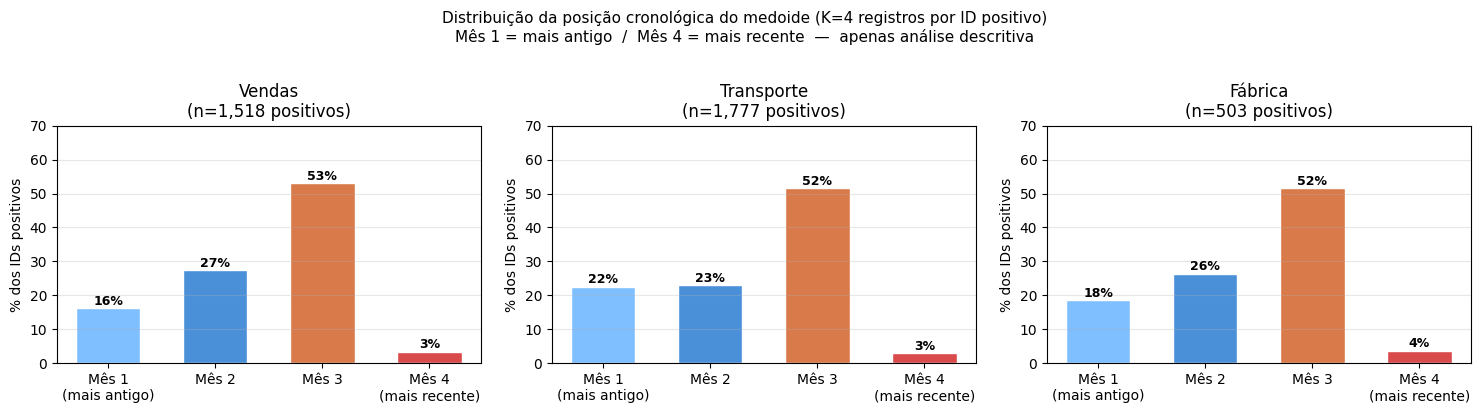

In [49]:

# ════════════════════════════════════════════════════════════════
# ANÁLISE DESCRITIVA — Seleção por medoide (sem alterar pipeline)
# ════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

_DATA_GOLD = Path.cwd().parent / "data" / "gold"
_COL_ID     = "id_colaborador"
_COL_DATA   = "dt_mes_ano"
_COL_TARGET = "fg_demitido_voluntario_4m"
_COL_GRUPO  = "ds_grupo"
_K          = 4

df_tt_an = pd.read_parquet(_DATA_GOLD / "base_features_tt.parquet")
df_tt_an[_COL_DATA] = pd.to_datetime(df_tt_an[_COL_DATA])
df_tt_an[_COL_ID]   = df_tt_an[_COL_ID].astype(str)

# Features numéricas contínuas
_meta_an  = {_COL_ID, _COL_DATA, _COL_TARGET, _COL_GRUPO}
_meta_an |= {c for c in df_tt_an.columns if c.startswith("fg_demitido_voluntario")}
_feat_an  = [c for c in df_tt_an.columns
             if c not in _meta_an and pd.api.types.is_numeric_dtype(df_tt_an[c])]

# ── Reduzir espaço de distância (mesma lógica do pipeline principal) ──
# Usa _reduzir_feat_dist (definida na célula de funções acima):
#   1. Remove _bin quando a versão contínua também está presente
#   2. Remove near-zero variance (std < 0.01)
#   3. Remove |corr(f, target)| < eps
_corr_an      = df_tt_an[_feat_an + [_COL_TARGET]].corr()[_COL_TARGET].abs().drop(_COL_TARGET)
_feat_dist_an = _reduzir_feat_dist(df_tt_an, _feat_an, corr_weights=_corr_an)

print(f"Features totais : {len(_feat_an)}")
print(f"Espaço distância: {len(_feat_dist_an)}  (-{len(_feat_an) - len(_feat_dist_an)} removidas)")
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, grupo in zip(axes, ["Vendas", "Transporte", "Fábrica"]):
    df_g   = df_tt_an[df_tt_an[_COL_GRUPO] == grupo].copy()
    desl_g = df_g[df_g[_COL_TARGET] == 1]

    posicoes = []

    for id_colab, grp in desl_g.groupby(_COL_ID):
        grp    = grp.sort_values(_COL_DATA).reset_index(drop=True)
        janela = grp.tail(_K).reset_index(drop=True)
        n      = len(janela)

        if n < 2:
            posicoes.append(1)
            continue

        # Matriz de features reduzida, normalizada pela std do grupo
        vals = janela[_feat_dist_an].fillna(0).to_numpy(dtype=float)
        std  = df_g[_feat_dist_an].std(ddof=1).fillna(1).replace(0, 1).to_numpy(dtype=float)
        vals_norm = vals / std

        soma_dist = np.zeros(n)
        for i in range(n):
            for j in range(n):
                if i != j:
                    soma_dist[i] += np.linalg.norm(vals_norm[i] - vals_norm[j])

        medoide_pos  = int(np.argmin(soma_dist))
        posicao_crono = (_K - n) + medoide_pos + 1
        posicoes.append(posicao_crono)

    s = pd.Series(posicoes)
    dist = s.value_counts().sort_index()
    pct  = (dist / dist.sum() * 100).round(1)

    print(f"=== {grupo} ({len(posicoes):,} IDs positivos) ===")
    for pos in range(1, _K + 1):
        bar = "█" * int(pct.get(pos, 0) / 2)
        print(f"  Mês {pos} (pos {'mais antigo' if pos==1 else ('mais recente' if pos==4 else 'intermediário'):<17}): "
              f"{int(dist.get(pos,0)):>5,}  {pct.get(pos,0):>5.1f}%  {bar}")
    print(f"  p50 posição = {s.median():.1f}  |  média = {s.mean():.2f}")
    print()

    ax.bar([1, 2, 3, 4],
           [pct.get(i, 0) for i in [1, 2, 3, 4]],
           color=["#7fbfff", "#4a90d9", "#d97a4a", "#d94a4a"],
           edgecolor="white", width=0.6)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(["Mês 1\n(mais antigo)", "Mês 2", "Mês 3", "Mês 4\n(mais recente)"])
    ax.set_ylabel("% dos IDs positivos")
    ax.set_ylim(0, 70)
    ax.set_title(f"{grupo}\n(n={len(posicoes):,} positivos)")
    ax.grid(axis="y", alpha=0.3)
    for xi, yi in enumerate([pct.get(i, 0) for i in [1, 2, 3, 4]], start=1):
        ax.text(xi, yi + 1, f"{yi:.0f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle(
    "Distribuição da posição cronológica do medoide (K=4 registros por ID positivo)\n"
    "Mês 1 = mais antigo  /  Mês 4 = mais recente  —  apenas análise descritiva",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()
plt.close()


In [50]:

print("Carregando bases ML-ready...")
df_tt_full  = pd.read_parquet(DATA_GOLD / "base_features_tt.parquet")
df_val_full = pd.read_parquet(DATA_GOLD / "base_features_val.parquet")

df_tt_full[COL_DATA]  = pd.to_datetime(df_tt_full[COL_DATA])
df_val_full[COL_DATA] = pd.to_datetime(df_val_full[COL_DATA])
df_tt_full[COL_ID]    = df_tt_full[COL_ID].astype(str)
df_val_full[COL_ID]   = df_val_full[COL_ID].astype(str)

print(f"  base_features_tt : {df_tt_full.shape[0]:,} × {df_tt_full.shape[1]}  "
      f"| grupos={df_tt_full[COL_GRUPO].value_counts().to_dict()}")
print(f"  base_features_val: {df_val_full.shape[0]:,} × {df_val_full.shape[1]}  "
      f"| grupos={df_val_full[COL_GRUPO].value_counts().to_dict()}")

# ── Controle: usar medoide ou todos os K registros ────────────
USE_MEDOID = False   # True = medoide (1 registro por ID positivo)
                     # False = todos os K registros mais recentes por ID positivo
print(f"\n  USE_MEDOID = {USE_MEDOID}")

# ── Pipeline de splits por grupo ─────────────────────────────
for GRUPO in GRUPOS:
    print(f"\n{'='*62}")
    print(f"GRUPO: {GRUPO}")
    print('='*62)

    grupo_splits = DATA_SPLITS / GRUPO
    grupo_models = MODELS / GRUPO
    grupo_splits.mkdir(parents=True, exist_ok=True)
    grupo_models.mkdir(parents=True, exist_ok=True)

    # ── Filtrar por grupo ─────────────────────────────────────
    df_tt  = df_tt_full[df_tt_full[COL_GRUPO] == GRUPO].copy().reset_index(drop=True)
    df_val = df_val_full[df_val_full[COL_GRUPO] == GRUPO].copy().reset_index(drop=True)

    # ── Filtro fg_ativo == 1 (defesa em profundidade) ─────────
    # Base_features_tt/val já foram filtradas em 02_build_dataset_m2.
    # Mantemos aqui para garantir se o parquet vier de uma execução anterior.
    if "fg_ativo" in df_tt.columns:
        n_tt_antes_fg  = len(df_tt)
        n_val_antes_fg = len(df_val)
        df_tt  = df_tt[df_tt["fg_ativo"] == 1].copy().reset_index(drop=True)
        df_val = df_val[df_val["fg_ativo"] == 1].copy().reset_index(drop=True)
        print(f"  Filtro fg_ativo==1: TT {n_tt_antes_fg:,} → {len(df_tt):,} | "
              f"Val {n_val_antes_fg:,} → {len(df_val):,}")

    # ── Filtro de elegibilidade: tempo de empresa > MIN_TEMPO_EMPRESA ─
    # Aplicado aqui (nos splits) para manter as bases gold integrais.
    _col_tempo = next(
        (c for c in ["vl_tempo_empresa", "tempo_empresa_meses", "vl_tempo_empresa_meses"]
         if c in df_tt.columns),
        None
    )
    if _col_tempo:
        n_tt_antes  = len(df_tt);  n_tt_ids_antes  = df_tt[COL_ID].nunique()
        n_val_antes = len(df_val); n_val_ids_antes = df_val[COL_ID].nunique()
        df_tt  = df_tt[df_tt[_col_tempo]   > MIN_TEMPO_EMPRESA].copy().reset_index(drop=True)
        df_val = df_val[df_val[_col_tempo]  > MIN_TEMPO_EMPRESA].copy().reset_index(drop=True)
        print(f"  Filtro {_col_tempo} > {MIN_TEMPO_EMPRESA}m:")
        print(f"    TT : {n_tt_antes:,} → {len(df_tt):,} linhas | "
              f"{n_tt_ids_antes:,} → {df_tt[COL_ID].nunique():,} IDs")
        print(f"    Val: {n_val_antes:,} → {len(df_val):,} linhas | "
              f"{n_val_ids_antes:,} → {df_val[COL_ID].nunique():,} IDs")
    else:
        print(f"  ⚠ Coluna de tempo de empresa não encontrada — filtro não aplicado")

    # Detectar target
    targets_str = [c for c in df_tt.columns if c == COL_TARGET]
    if not targets_str:
        print(f"  ⚠ Target não encontrado — pulando {GRUPO}")
        continue
    col_target_grupo = targets_str[0]

    print(f"  TT : {df_tt.shape[0]:,} reg | {df_tt[COL_ID].nunique():,} IDs | "
          f"turnover: {df_tt[col_target_grupo].mean():.2%}")
    print(f"  Val: {df_val.shape[0]:,} reg | {df_val[COL_ID].nunique():,} IDs | "
          f"turnover: {df_val[col_target_grupo].mean():.2%}")

    # ── Classificar features para o medoide ──────────────────
    META = {COL_ID, COL_DATA, col_target_grupo}
    META.update(c for c in df_tt.columns if c.startswith("fg_demitido_voluntario"))
    # Flags de demissão/status nunca entram como feature (data leakage)
    META.update(c for c in df_tt.columns if c.startswith("fg_"))
    for col_meta in ["ds_grupo", "agrupamento_final"]:
        if col_meta in df_tt.columns:
            META.add(col_meta)

    FEATURE_COLS = [c for c in df_tt.columns if c not in META]

    bin_ord_cols = [c for c in FEATURE_COLS
                    if c.endswith("_bin") and pd.api.types.is_numeric_dtype(df_tt[c])]
    ohe_bin_cols = [c for c in FEATURE_COLS
                    if pd.api.types.is_numeric_dtype(df_tt[c])
                    and df_tt[c].nunique(dropna=True) <= 2
                    and not c.endswith("_bin")]
    cat_cols = bin_ord_cols + ohe_bin_cols

    num_feats   = [c for c in FEATURE_COLS
                   if pd.api.types.is_numeric_dtype(df_tt[c]) and c not in cat_cols]
    num_est     = [c for c in num_feats if any(kw in c.lower() for kw in KEYWORDS_ESTAVEIS)]
    num_comport = [c for c in num_feats if c not in num_est]

    extremos_bin = {c: {"min": df_tt[c].min(), "max": df_tt[c].max()} for c in bin_ord_cols}

    # ── Split 70/30 por ID (estratificado pelo target) ────────
    id_target = (
        df_tt.groupby(COL_ID)[col_target_grupo]
        .max().reset_index()
        .rename(columns={col_target_grupo: "turnover_flag"})
    )

    ids_train, ids_test = train_test_split(
        id_target[COL_ID].values,
        test_size=PROP_TEST,
        stratify=id_target["turnover_flag"].values,
        random_state=RNG_SEED,
    )

    assert set(ids_train).isdisjoint(set(ids_test)), f"[{GRUPO}] Vazamento train↔test!"

    df_train_raw = df_tt[df_tt[COL_ID].isin(ids_train)].copy()
    df_test_raw  = df_tt[df_tt[COL_ID].isin(ids_test)].copy()

    print(f"\n  Split pré-medoide:")
    print(f"    Treino: {df_train_raw[COL_ID].nunique():,} IDs | {len(df_train_raw):,} reg")
    print(f"    Teste : {df_test_raw[COL_ID].nunique():,} IDs | {len(df_test_raw):,} reg")

    # ── Pesos de correlação para seleção iterativa de ativos ──
    # Calculados no painel completo de treino (antes do subsampling).
    # Features monotônicas crescentes (tempo_empresa, idade) são excluídas.
    feature_cols_dist = [
        c for c in num_feats + cat_cols
        if not any(kw in c.lower() for kw in KEYWORDS_MONOTON)
    ]
    corr_with_target = (
        df_train_raw[feature_cols_dist + [col_target_grupo]]
        .corr()[col_target_grupo]
        .abs()
        .drop(col_target_grupo)
    )
    n_above_eps = int((corr_with_target >= CORR_EPS).sum())
    print(f"\n  Correlação c/ target: {len(feature_cols_dist)} features analisadas  |  "
          f"cor≥{CORR_EPS}: {n_above_eps}  |  "
          f"top-3: {corr_with_target.nlargest(3).index.tolist()}")

    # ── Reduzir espaço de features para cálculo de distância ──────
    # Remove: (1) pares _bin redundantes, (2) near-zero variance, (3) |corr|<eps.
    # Afeta apenas medoide e subsampling de ativos — features do modelo intactas.
    feature_cols_dist_reduzido = _reduzir_feat_dist(
        df_train_raw, feature_cols_dist, corr_weights=corr_with_target
    )
    print(f"  Espaço de distância: {len(feature_cols_dist)} → {len(feature_cols_dist_reduzido)} "
          f"(-{len(feature_cols_dist) - len(feature_cols_dist_reduzido)} removidas)")

    # ── Aplicar medoide ou todos os K registros (pós-split) ───
    df_train, slope_cols = construir_proto_e_mesclar(
        df_train_raw, COL_ID, COL_DATA, col_target_grupo,
        num_est, num_comport, cat_cols, extremos_bin, K=JANELA_PREDICAO,
        corr_weights=corr_with_target, feature_cols_dist=feature_cols_dist_reduzido,
        use_medoid=USE_MEDOID, feat_dist_cols=feature_cols_dist_reduzido,
    )
    df_test, _ = construir_proto_e_mesclar(
        df_test_raw, COL_ID, COL_DATA, col_target_grupo,
        num_est, num_comport, cat_cols, extremos_bin, K=JANELA_PREDICAO,
        corr_weights=corr_with_target, feature_cols_dist=feature_cols_dist_reduzido,
        use_medoid=USE_MEDOID, feat_dist_cols=feature_cols_dist_reduzido,
    )

    # Val: NÃO passa por construir_proto_e_mesclar — base pura (snapshots mensais reais)
    # Apenas scaler.transform será aplicado abaixo. Isso garante que a distribuição
    # de target (~15%) e de negativos (~2,8 rows/ID) reflita a população real.

    modo_label = "medoide" if USE_MEDOID else f"todos os K={JANELA_PREDICAO} registros"
    print(f"\n  Após seleção ({modo_label}):")
    print(f"    Treino: {df_train[COL_ID].nunique():,} IDs | {len(df_train):,} reg | "
          f"turnover: {df_train[col_target_grupo].mean():.2%}")
    print(f"    Teste : {df_test[COL_ID].nunique():,} IDs | {len(df_test):,} reg | "
          f"turnover: {df_test[col_target_grupo].mean():.2%}")
    print(f"    Val   : {df_val[COL_ID].nunique():,} IDs | {len(df_val):,} reg | "
          f"turnover: {df_val[col_target_grupo].mean():.2%}  [pura — sem construir]")

    # ── StandardScaler nas contínuas (fit no treino) ──────────
    META_SCALE = {COL_ID, COL_DATA, col_target_grupo}
    META_SCALE.update(c for c in df_train.columns if c.startswith("fg_demitido_voluntario"))
    # Flags fg_* excluídas do scaler (não são features)
    META_SCALE.update(c for c in df_train.columns if c.startswith("fg_"))
    for col_meta in ["ds_grupo", "agrupamento_final"]:
        if col_meta in df_train.columns:
            META_SCALE.add(col_meta)

    scale_cols = [
        c for c in df_train.columns
        if c not in META_SCALE
        and pd.api.types.is_numeric_dtype(df_train[c])
        and not c.endswith("_bin")
        and df_train[c].nunique(dropna=True) > 2
    ]

    scaler = StandardScaler()
    scaler.fit(df_train[scale_cols])
    df_train[scale_cols] = scaler.transform(df_train[scale_cols])
    df_test[scale_cols]  = scaler.transform(df_test[scale_cols])

    # Val: transformar apenas as colunas em comum com scale_cols
    scale_cols_val = [c for c in scale_cols if c in df_val.columns]
    df_val[scale_cols_val] = scaler.transform(df_val[scale_cols_val])

    tv_val = df_val[col_target_grupo].mean() if col_target_grupo in df_val.columns else float("nan")
    print(f"\n  Scaler: {len(scale_cols)} colunas escalonadas")
    print(f"  Val: {df_val[COL_ID].nunique():,} IDs | {len(df_val):,} reg | "
          f"turnover: {tv_val:.2%}")

    # ── Remover colunas fg_* antes de salvar (defesa em profundidade) ─
    # O target (col_target_grupo) é preservado; todas as demais flags são excluídas.
    fg_drop = [c for c in df_train.columns
               if c.startswith("fg_") and c != col_target_grupo]
    df_train = df_train.drop(columns=fg_drop, errors="ignore")
    df_test  = df_test.drop(columns=fg_drop, errors="ignore")
    fg_drop_val = [c for c in df_val.columns
                   if c.startswith("fg_") and c != col_target_grupo]
    df_val   = df_val.drop(columns=fg_drop_val, errors="ignore")
    if fg_drop:
        print(f"  Colunas fg_* removidas dos splits: {fg_drop}")

    # ── Salvar splits e artefatos ─────────────────────────────
    paths = {
        "train": grupo_splits / "train.parquet",
        "test" : grupo_splits / "test.parquet",
        "val"  : grupo_splits / "val.parquet",
    }
    df_train.to_parquet(paths["train"], index=False)
    df_test.to_parquet(paths["test"],   index=False)
    df_val.to_parquet(paths["val"],     index=False)

    scaler_path     = grupo_models / "standard_scaler.joblib"
    scale_cols_path = grupo_splits / "scaler_cols.json"

    joblib.dump(scaler, scaler_path)
    with open(scale_cols_path, "w", encoding="utf-8") as f:
        json.dump({
            "scale_cols"          : scale_cols,
            "slope_cols"          : slope_cols,
            "col_id"              : COL_ID,
            "col_target"          : col_target_grupo,
            "col_data"            : COL_DATA,
            "n_scale_cols"        : len(scale_cols),
            "grupo"               : GRUPO,
            "use_medoid"          : USE_MEDOID,
            "min_tempo_empresa"   : MIN_TEMPO_EMPRESA,
        }, f, indent=2, ensure_ascii=False)

    print(f"\n  Outputs em splits/{GRUPO}/:")
    for nome, p in paths.items():
        mb = p.stat().st_size / 1e6
        print(f"    {nome:<6} → {p.name}  ({mb:.1f} MB)")
    print(f"    scaler_cols.json  |  standard_scaler.joblib → models/{GRUPO}/")

print(f"\n{'='*62}")
print(f"✓ Splits gerados para {len(GRUPOS)} grupos: {GRUPOS}")
print(f"  USE_MEDOID = {USE_MEDOID}")
print(f"  Filtro aplicado: vl_tempo_empresa > {MIN_TEMPO_EMPRESA} meses")
print(f"{'='*62}")


Carregando bases ML-ready...
  base_features_tt : 97,670 × 823  | grupos={'Transporte': 48144, 'Vendas': 37081, 'Fábrica': 12445}
  base_features_val: 15,393 × 823  | grupos={'Transporte': 7775, 'Vendas': 5794, 'Fábrica': 1824}

  USE_MEDOID = False

GRUPO: Vendas
  Filtro vl_tempo_empresa > 3m:
    TT : 37,081 → 33,845 linhas | 3,737 → 3,292 IDs
    Val: 5,794 → 5,049 linhas | 2,134 → 1,821 IDs
  TT : 33,845 reg | 3,292 IDs | turnover: 11.28%
  Val: 5,049 reg | 1,821 IDs | turnover: 9.88%

  Split pré-medoide:
    Treino: 2,304 IDs | 23,627 reg
    Teste : 988 IDs | 10,218 reg

  Correlação c/ target: 784 features analisadas  |  cor≥0.05: 137  |  top-3: ['vl_remuneracao_variavel_min_3m_bin', 'vl_remuneracao_variavel_bin', 'vl_remuneracao_variavel_mean_3m_bin']
  Espaço de distância: 784 → 75 (-709 removidas)

  Após seleção (todos os K=4 registros):
    Treino: 2,304 IDs | 8,230 reg | turnover: 32.31%
    Teste : 988 IDs | 3,568 reg | turnover: 32.48%
    Val   : 1,821 IDs | 5,049 reg

## 3 · Split por ID Colaborador (SPEC §5)

**Regra obrigatória:** todos os registros de um colaborador vão para o mesmo conjunto.
O split é feito ao nível de `id_colaborador` e depois os registros são atribuídos conforme o split do ID.

**Estratificação:** pela taxa de turnover voluntário de cada colaborador
(se o colaborador tem) algum registro target=1 nas janelas analisadas).

In [51]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [52]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [53]:
# Processamento consolidado no loop por grupo acima (célula anterior).


## 4 · StandardScaler nas Contínuas (SPEC §10)

Escalonar apenas as features **contínuas** — sem escalonar:
- Colunas `_bin` (ordinais 1–5): já em escala ordinal interpretável
- Colunas OHE (binárias 0/1): qualquer coluna com ≤ 2 valores únicos
- Colunas de metadados: id, data, target

**O scaler é fitado exclusivamente no treino** e transformado em val e teste.

In [54]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [55]:
# Processamento consolidado no loop por grupo acima (célula anterior).


## 5 · Verificação Final dos Splits

In [56]:
# Processamento consolidado no loop por grupo acima (célula anterior).


## 6 · Salvar Splits e Artefatos

In [57]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [58]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [59]:
# Processamento consolidado no loop por grupo acima (célula anterior).


In [60]:

# Distribuição 0/1 por grupo × mês (pré-split, base_features_tt completa)
tbl = (
    df_tt_full
    .groupby([COL_GRUPO, COL_DATA, COL_TARGET])
    .size()
    .unstack(COL_TARGET, fill_value=0)
    .rename(columns={0: "neg", 1: "pos"})
    .assign(total=lambda d: d["neg"] + d["pos"],
            tx=lambda d: (d["pos"] / (d["neg"] + d["pos"]) * 100).round(1))
)

for grupo, sub in tbl.groupby(level=0):
    s = sub.droplevel(0)
    print(f"\n{grupo}  (neg_total={s['neg'].sum():,}  pos_total={s['pos'].sum():,}  tx_media={s['pos'].sum()/s['total'].sum()*100:.1f}%)")
    print(f"  {'mês':<12} {'neg':>7} {'pos':>6} {'total':>7} {'tx%':>6}")
    for mes, row in s.iterrows():
        print(f"  {str(mes):<12} {row['neg']:>7,} {row['pos']:>6,} {row['total']:>7,} {row['tx']:>5.1f}%")



Fábrica  (neg_total=10,943  pos_total=1,502  tx_media=12.1%)
  mês              neg    pos   total    tx%
  2024-01-01 00:00:00   743.0  109.0   852.0  12.8%
  2024-02-01 00:00:00   718.0   94.0   812.0  11.6%
  2024-03-01 00:00:00   690.0   97.0   787.0  12.3%
  2024-04-01 00:00:00   674.0   84.0   758.0  11.1%
  2024-05-01 00:00:00   655.0   94.0   749.0  12.6%
  2024-06-01 00:00:00   639.0   85.0   724.0  11.7%
  2024-07-01 00:00:00   633.0   82.0   715.0  11.5%
  2024-08-01 00:00:00   647.0   87.0   734.0  11.9%
  2024-09-01 00:00:00   689.0   95.0   784.0  12.1%
  2024-10-01 00:00:00   667.0   99.0   766.0  12.9%
  2024-11-01 00:00:00   646.0   92.0   738.0  12.5%
  2024-12-01 00:00:00   626.0   95.0   721.0  13.2%
  2025-01-01 00:00:00   612.0   96.0   708.0  13.6%
  2025-02-01 00:00:00   599.0   87.0   686.0  12.7%
  2025-03-01 00:00:00   587.0   76.0   663.0  11.5%
  2025-04-01 00:00:00   566.0   69.0   635.0  10.9%
  2025-05-01 00:00:00   552.0   61.0   613.0  10.0%

Transpor